# Experiment 5A
## Decision Tree Classifier from Scratch
## Experiment done by Swarnab Das. BTECH/CSE/24/080

In [1]:
# Experiment done by Swarnab Das. BTECH/CSE/24/080
import numpy as np
from collections import Counter

class Node:

    def __init__(
        self,
        feature=None,
        threshold=None,
        left=None,
        right=None,
        value=None
    ):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value


class DecisionTreeClassifierScratch:

    def __init__(
        self,
        max_depth=3,
        min_samples_split=2
    ):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.root = None
    def entropy(self, y):

        if len(y) == 0:
            return 0

        counts = np.bincount(y)

        probabilities = (
            counts[counts > 0] / len(y)
        )

        entropy = -np.sum(
            probabilities *
            np.log2(probabilities)
        )

        return entropy

    def information_gain(
        self,
        y,
        y_left,
        y_right
    ):

        parent_entropy = self.entropy(y)

        n = len(y)
        n_left = len(y_left)
        n_right = len(y_right)

        if n_left == 0 or n_right == 0:
            return 0

        weighted_entropy = (
            (n_left / n) * self.entropy(y_left)
            + (n_right / n) * self.entropy(y_right)
        )

        gain = (
            parent_entropy -
            weighted_entropy
        )

        return gain

    def best_split(self, X, y):

        best_gain = -1
        best_feature = None
        best_threshold = None

        n_samples, n_features = X.shape

        for feature in range(n_features):

            feature_values = X[:, feature]

            thresholds = np.unique(feature_values)

            for threshold in thresholds:

                left_indices = (
                    feature_values <= threshold
                )

                right_indices = (
                    feature_values > threshold
                )

                y_left = y[left_indices]
                y_right = y[right_indices]

                if len(y_left) == 0 or len(y_right) == 0:
                    continue

                gain = self.information_gain(
                    y,
                    y_left,
                    y_right
                )

                if gain > best_gain:
                    best_gain = gain
                    best_feature = feature
                    best_threshold = threshold

        return (
            best_feature,
            best_threshold,
            best_gain
        )
    def build_tree(
        self,
        X,
        y,
        depth=0
    ):

        n_samples = len(y)

        n_classes = len(
            np.unique(y)
        )

        if (
            depth >= self.max_depth
            or n_classes == 1
            or n_samples < self.min_samples_split
        ):

            leaf_value = Counter(
                y
            ).most_common(1)[0][0]

            return Node(
                value=leaf_value
            )

        (
            feature,
            threshold,
            gain
        ) = self.best_split(
            X,
            y
        )

        if feature is None or gain <= 0:

            leaf_value = Counter(
                y
            ).most_common(1)[0][0]

            return Node(
                value=leaf_value
            )

        left_indices = (
            X[:, feature] <= threshold
        )

        right_indices = (
            X[:, feature] > threshold
        )

        X_left = X[left_indices]
        y_left = y[left_indices]

        X_right = X[right_indices]
        y_right = y[right_indices]

        left_child = self.build_tree(
            X_left,
            y_left,
            depth + 1
        )

        right_child = self.build_tree(
            X_right,
            y_right,
            depth + 1
        )

        return Node(
            feature=feature,
            threshold=threshold,
            left=left_child,
            right=right_child
        )

    def fit(self, X, y):

        X = np.array(
            X,
            dtype=float
        )

        y = np.array(
            y,
            dtype=int
        )

        self.root = self.build_tree(
            X,
            y
        )

    def predict_one(
        self,
        x,
        node
    ):

        if node.value is not None:
            return node.value

        if x[node.feature] <= node.threshold:

            return self.predict_one(
                x,
                node.left
            )

        return self.predict_one(
            x,
            node.right
        )

    def predict(self, X):

        X = np.array(
            X,
            dtype=float
        )

        predictions = []

        for x in X:

            predictions.append(
                self.predict_one(
                    x,
                    self.root
                )
            )

        return np.array(predictions)


# ============================================================
# Dataset
# ============================================================

X = np.array([
    [1, 55],
    [2, 60],
    [3, 65],
    [4, 70],
    [5, 75],
    [6, 80],
    [7, 85],
    [8, 90]
])

y = np.array([
    0, 0, 0, 1,
    1, 1, 1, 1
])



X_train = X[:6]
y_train = y[:6]

X_test = X[6:]
y_test = y[6:]


print("Training Data:")
print(X_train)

print("\nTraining Labels:")
print(y_train)

print("\nTesting Data:")
print(X_test)

print("\nTesting Labels:")
print(y_test)

tree = DecisionTreeClassifierScratch(
    max_depth=3
)


initial_entropy = tree.entropy(
    y_train
)

print("\nInitial Entropy:")

print(
    round(
        initial_entropy,
        4
    )
)


(
    feature,
    threshold,
    gain
) = tree.best_split(
    X_train,
    y_train
)

print("\nBest Split")
print("-------------------------")

print(
    "Feature Index:",
    feature
)

print(
    "Threshold:",
    threshold
)

print(
    "Information Gain:",
    round(
        gain,
        4
    )
)

tree.fit(
    X_train,
    y_train
)

y_pred = tree.predict(
    X_test
)

print("\nActual Labels:")
print(y_test)

print("\nPredicted Labels:")
print(y_pred)
accuracy = np.mean(
    y_test == y_pred
)

print(
    "\nAccuracy:",
    round(
        accuracy,
        4
    )
)

print(
    "Accuracy (%):",
    round(
        accuracy * 100,
        2
    )
)

Training Data:
[[ 1 55]
 [ 2 60]
 [ 3 65]
 [ 4 70]
 [ 5 75]
 [ 6 80]]

Training Labels:
[0 0 0 1 1 1]

Testing Data:
[[ 7 85]
 [ 8 90]]

Testing Labels:
[1 1]

Initial Entropy:
1.0

Best Split
-------------------------
Feature Index: 0
Threshold: 3
Information Gain: 1.0

Actual Labels:
[1 1]

Predicted Labels:
[1 1]

Accuracy: 1.0
Accuracy (%): 100.0


# Experiment 5B
## Decision Tree Regressor from Scratch
## Experiment done by Swarnab Das. BTECH/CSE/24/080

In [3]:

# Experiment done by Swarnab Das. BTECH/CSE/24/080

import numpy as np

class Node:

    def __init__(
        self,
        feature=None,
        threshold=None,
        left=None,
        right=None,
        value=None
    ):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value


class DecisionTreeRegressorScratch:

    def __init__(
        self,
        max_depth=3,
        min_samples_split=2
    ):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.root = None

    # --------------------------------------------------------
    # Mean Squared Error
    # --------------------------------------------------------

    def mse(self, y):

        if len(y) == 0:
            return 0

        mean_value = np.mean(y)

        return np.mean(
            (y - mean_value) ** 2
        )

    # --------------------------------------------------------
    # Weighted MSE
    # --------------------------------------------------------

    def weighted_mse(
        self,
        y_left,
        y_right
    ):

        n = (
            len(y_left) +
            len(y_right)
        )

        if n == 0:
            return 0

        return (
            (len(y_left) / n) * self.mse(y_left)
            +
            (len(y_right) / n) * self.mse(y_right)
        )

    # --------------------------------------------------------
    # Find Best Split
    # --------------------------------------------------------

    def best_split(self, X, y):

        best_mse = float("inf")

        best_feature = None
        best_threshold = None

        n_samples, n_features = X.shape

        for feature in range(n_features):

            feature_values = X[:, feature]

            thresholds = np.unique(
                feature_values
            )

            for threshold in thresholds:

                left_indices = (
                    feature_values <= threshold
                )

                right_indices = (
                    feature_values > threshold
                )

                y_left = y[left_indices]
                y_right = y[right_indices]

                if (
                    len(y_left) == 0
                    or len(y_right) == 0
                ):
                    continue

                split_mse = self.weighted_mse(
                    y_left,
                    y_right
                )

                if split_mse < best_mse:
                    best_mse = split_mse
                    best_feature = feature
                    best_threshold = threshold

        return (
            best_feature,
            best_threshold,
            best_mse
        )

    # --------------------------------------------------------
    # Build Tree
    # --------------------------------------------------------

    def build_tree(
        self,
        X,
        y,
        depth=0
    ):

        n_samples = len(y)

        if (
            depth >= self.max_depth
            or n_samples < self.min_samples_split
            or np.all(y == y[0])
        ):

            leaf_value = np.mean(y)

            return Node(
                value=leaf_value
            )

        (
            feature,
            threshold,
            split_mse
        ) = self.best_split(
            X,
            y
        )

        if feature is None:

            leaf_value = np.mean(y)

            return Node(
                value=leaf_value
            )

        left_indices = (
            X[:, feature] <= threshold
        )

        right_indices = (
            X[:, feature] > threshold
        )

        X_left = X[left_indices]
        y_left = y[left_indices]

        X_right = X[right_indices]
        y_right = y[right_indices]

        left_child = self.build_tree(
            X_left,
            y_left,
            depth + 1
        )

        right_child = self.build_tree(
            X_right,
            y_right,
            depth + 1
        )

        return Node(
            feature=feature,
            threshold=threshold,
            left=left_child,
            right=right_child
        )

    # --------------------------------------------------------
    # Train
    # --------------------------------------------------------

    def fit(self, X, y):

        X = np.array(
            X,
            dtype=float
        )

        y = np.array(
            y,
            dtype=float
        )

        self.root = self.build_tree(
            X,
            y
        )

    # --------------------------------------------------------
    # Predict One Sample
    # --------------------------------------------------------

    def predict_one(
        self,
        x,
        node
    ):

        if node.value is not None:
            return node.value

        if x[node.feature] <= node.threshold:

            return self.predict_one(
                x,
                node.left
            )

        return self.predict_one(
            x,
            node.right
        )

    # --------------------------------------------------------
    # Predict Multiple Samples
    # --------------------------------------------------------

    def predict(self, X):

        X = np.array(
            X,
            dtype=float
        )

        predictions = []

        for x in X:

            predictions.append(
                self.predict_one(
                    x,
                    self.root
                )
            )

        return np.array(predictions)


# ============================================================
# Dataset
# ============================================================

X = np.array([
    [8, 2],
    [10, 2],
    [12, 3],
    [14, 3],
    [16, 4],
    [18, 4],
    [20, 5],
    [22, 5]
])

y = np.array([
    40,
    45,
    52,
    60,
    68,
    75,
    85,
    95
])


# ============================================================
# Train-Test Split
# ============================================================

X_train = X[:6]
y_train = y[:6]

X_test = X[6:]
y_test = y[6:]


print("Training Data:")
print(X_train)

print("\nTraining Target:")
print(y_train)

print("\nTesting Data:")
print(X_test)

print("\nTesting Target:")
print(y_test)


# ============================================================
# Create Model
# ============================================================

tree = DecisionTreeRegressorScratch(
    max_depth=3
)


# ============================================================
# Initial MSE
# ============================================================

initial_mse = tree.mse(
    y_train
)

print("\nInitial MSE:")

print(
    round(
        initial_mse,
        4
    )
)


# ============================================================
# Find Best Split
# ============================================================

(
    feature,
    threshold,
    split_mse
) = tree.best_split(
    X_train,
    y_train
)

print("\nBest Split")
print("-------------------------")

print(
    "Feature Index:",
    feature
)

print(
    "Threshold:",
    threshold
)

print(
    "Weighted MSE:",
    round(
        split_mse,
        4
    )
)


# ============================================================
# Train
# ============================================================

tree.fit(
    X_train,
    y_train
)


# ============================================================
# Prediction
# ============================================================

y_pred = tree.predict(
    X_test
)


# ============================================================
# Results
# ============================================================

print("\nActual Values:")
print(y_test)

print("\nPredicted Values:")

print(
    np.round(
        y_pred,
        2
    )
)


# ============================================================
# Performance Metrics
# ============================================================

mae = np.mean(
    np.abs(
        y_test - y_pred
    )
)

mse = np.mean(
    (
        y_test - y_pred
    ) ** 2
)

rmse = np.sqrt(
    mse
)

ss_res = np.sum(
    (
        y_test - y_pred
    ) ** 2
)

ss_tot = np.sum(
    (
        y_test - np.mean(y_test)
    ) ** 2
)

r2 = 1 - (
    ss_res / ss_tot
)


print("\n===================================")
print("       DECISION TREE REGRESSION")
print("===================================")

print(
    "MAE:",
    round(mae, 4)
)

print(
    "MSE:",
    round(mse, 4)
)

print(
    "RMSE:",
    round(rmse, 4)
)

print(
    "R2:",
    round(r2, 4)
)

Training Data:
[[ 8  2]
 [10  2]
 [12  3]
 [14  3]
 [16  4]
 [18  4]]

Training Target:
[40 45 52 60 68 75]

Testing Data:
[[20  5]
 [22  5]]

Testing Target:
[85 95]

Initial MSE:
151.8889

Best Split
-------------------------
Feature Index: 0
Threshold: 12
Weighted MSE: 30.8889

Actual Values:
[85 95]

Predicted Values:
[75. 75.]

       DECISION TREE REGRESSION
MAE: 15.0
MSE: 250.0
RMSE: 15.8114
R2: -9.0


# Experiment 5C
## Decision Tree Classifier using Scikit Learn
## Experiment done by Swarnab Das. BTECH/CSE/24/080

    Actual  Predicted
0        0          0
1        2          2
2        1          1
3        1          1
4        0          0
5        1          1
6        0          0
7        0          0
8        2          2
9        1          1
10       2          2
11       2          2
12       2          2
13       1          1
14       0          0


Confusion Matrix----------->
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


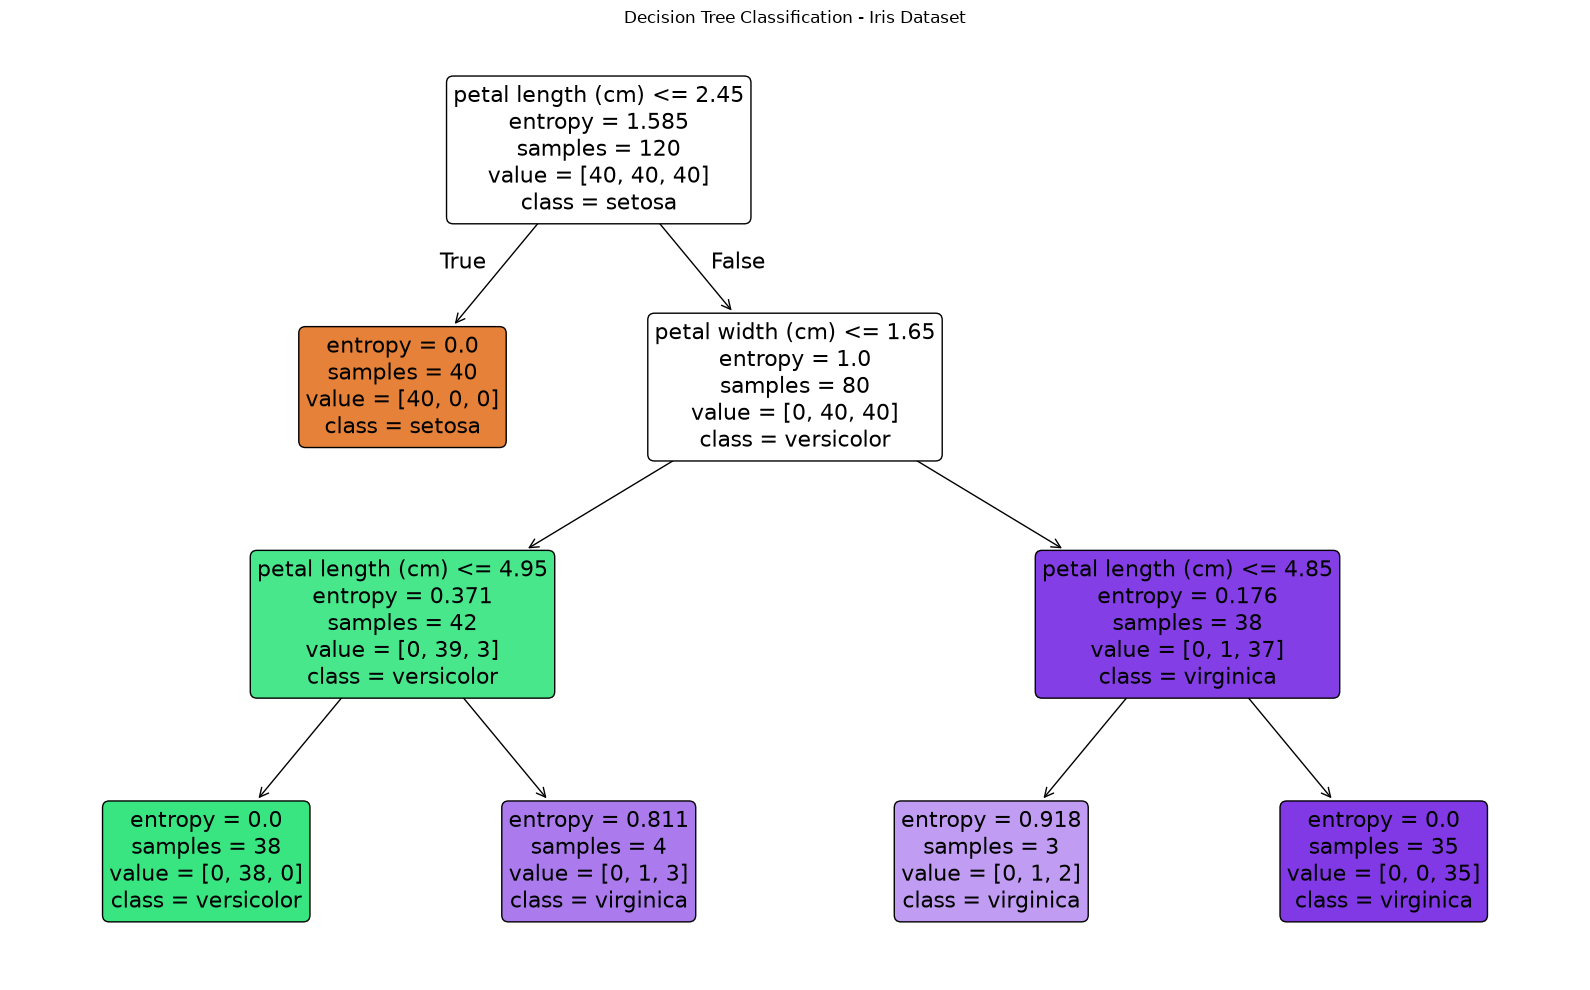

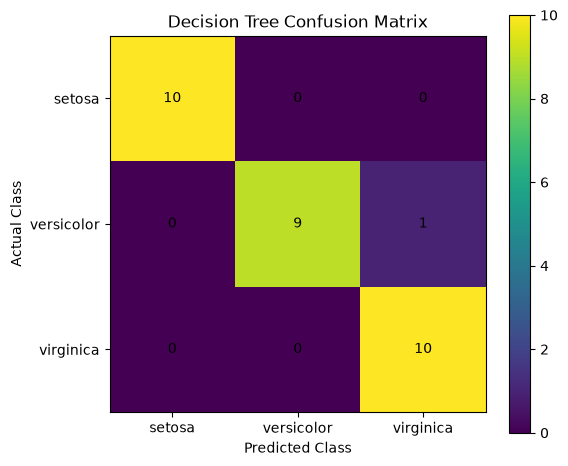

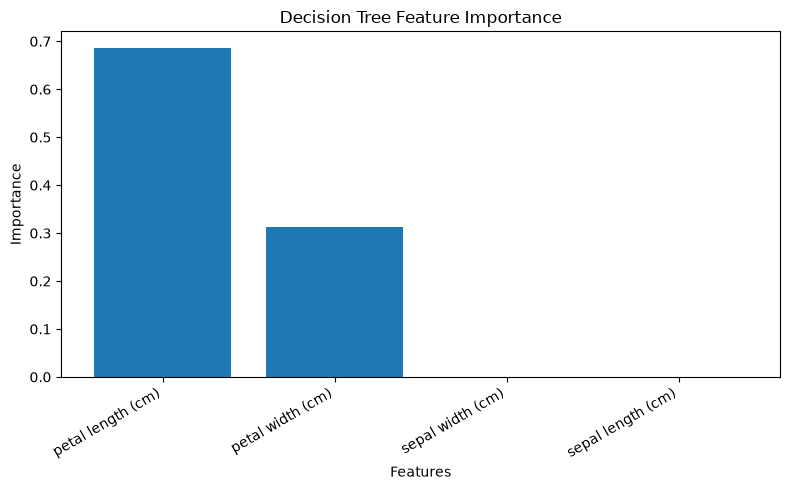

In [8]:
# Experiment done by Swarnab Das. BTECH/CSE/24/080
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree

iris = load_iris()
from sklearn . metrics import (
    accuracy_score ,
    confusion_matrix ,
    classification_report
)
x = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

#DATAFRAME CREATION
df = pd.DataFrame(
    x,
    columns = feature_names
)
df["Target"] = y
df["Species"] = df["Target"].map(
    {
        0: "setosa",
        1: "versicolor",
        2: "virginica"
    }
)
'''
print(df.shape)
print("First Five Records: ")
print(df.head())

'''
#Train Test Split
x_train,x_test,y_train,y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
#Model Initialization
model = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=3,
    random_state=42
)
#Fitting the Model
model.fit(
    x_train,
    y_train
)
#Prediction
y_pred = model.predict(x_test)
results = pd.DataFrame(
    {
        "Actual": y_test,
        "Predicted": y_pred,
    }
)
print(results.head(15))
#Finally the confusion Matrix
c_matrix = confusion_matrix(y_test,y_pred)
print("\n\nConfusion Matrix----------->")
print(c_matrix)
plt.figure(
    figsize=(16, 10)
)

plot_tree(
    model,
    feature_names=feature_names,
    class_names=target_names,
    filled=True,
    rounded=True
)

plt.title(
    "Decision Tree Classification - Iris Dataset"
)

plt.tight_layout()

plt.show()
#Confusion Matrix Plot
plt.figure(
    figsize=(6, 5)
)

plt.imshow(
    c_matrix,
    interpolation="nearest"
)

plt.title(
    "Decision Tree Confusion Matrix"
)

plt.xlabel(
    "Predicted Class"
)
plt.ylabel(
    "Actual Class"
)
plt.xticks(
    range(len(target_names)),
    target_names
)
plt.yticks(
    range(len(target_names)),
    target_names
)
for i in range(c_matrix.shape[0]):
    for j in range(c_matrix.shape[1]):
        plt.text(
            j,
            i,
            c_matrix[i, j],
            ha="center",
            va="center"
        )
plt.colorbar()
plt.tight_layout()
plt.show()
#Feature Plot
importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)
plt.figure(
    figsize=(8, 5)
)
plt.bar(
    importance["Feature"],
    importance["Importance"]
)
plt.xlabel(
    "Features"
)
plt.ylabel(
    "Importance"
)
plt.title(
    "Decision Tree Feature Importance"
)
plt.xticks(
    rotation=30,
    ha="right"
)
plt.tight_layout()
plt.show()

# Experiment 5D
## Decision Tree Regressor using Scikit Learn
## Experiment done by Swarnab Das. BTECH/CSE/24/080


Feature Importance:
      Feature  Importance
0      MedInc    0.771212
5    AveOccup    0.128407
1    HouseAge    0.041621
2    AveRooms    0.031261
6    Latitude    0.022049
4  Population    0.002485
7   Longitude    0.002097
3   AveBedrms    0.000869


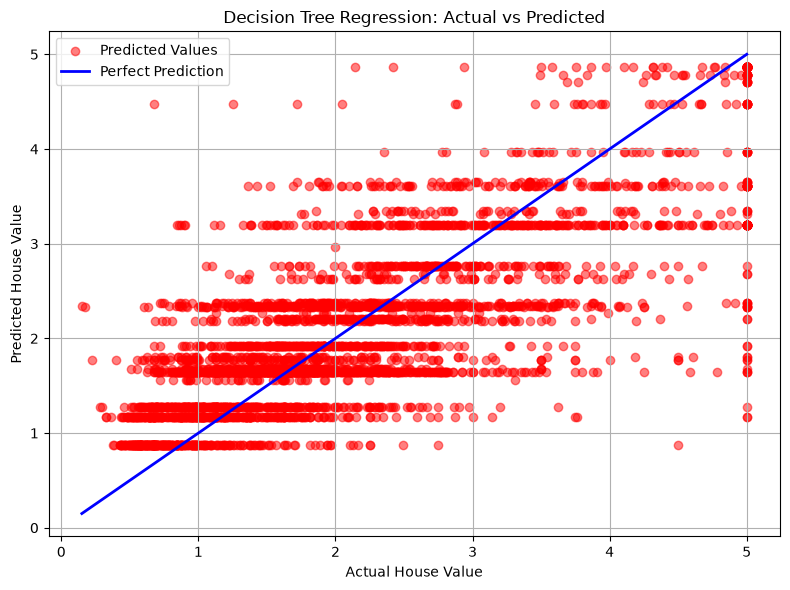

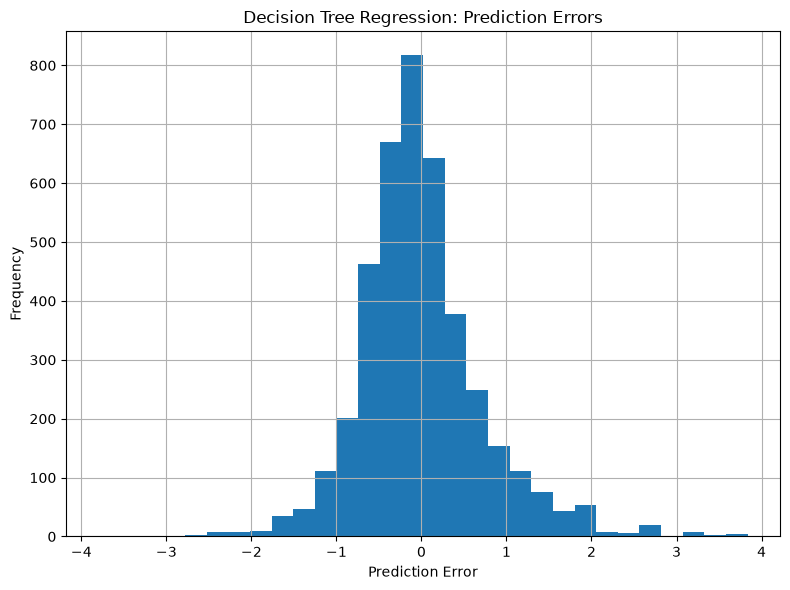

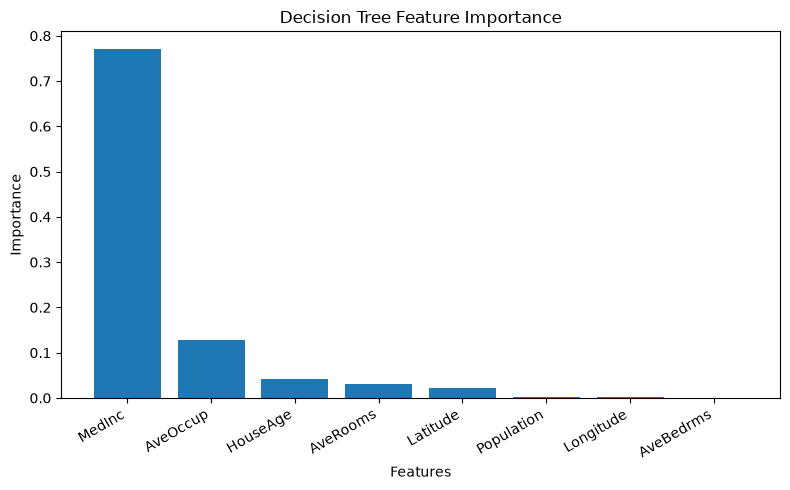

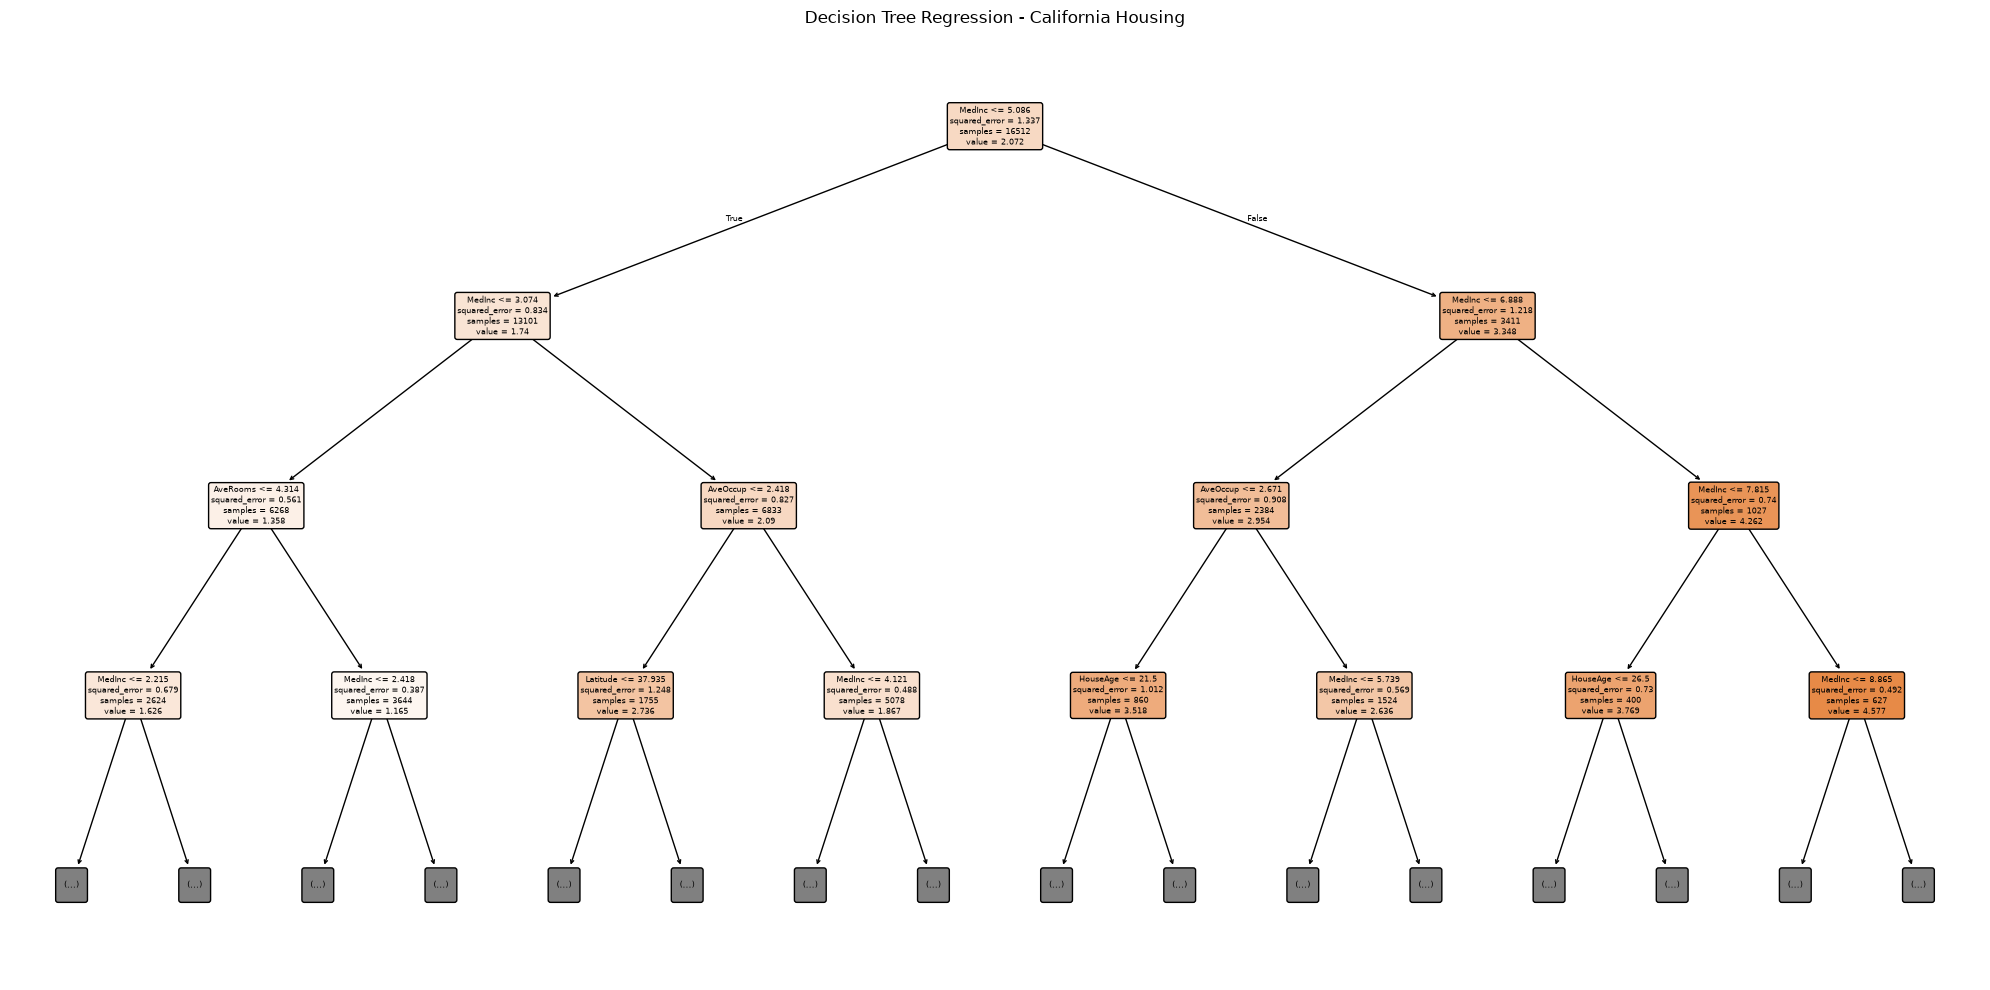

In [15]:
# Experiment done by Swarnab Das. BTECH/CSE/24/080
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import (fetch_california_housing)
from sklearn.model_selection import train_test_split
from sklearn.tree import (DecisionTreeRegressor,plot_tree)
from sklearn . metrics import (mean_absolute_error,mean_squared_error ,r2_score)
#---------------

housing =fetch_california_housing()
X = housing.data
y= housing.target
feature_names = housing.feature_names
#-------------------------
df = pd.DataFrame (X,columns=feature_names)
df["MedHouseValue"] = y

X = df[feature_names].values
y = df["MedHouseValue"].values
#Applying Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
model = DecisionTreeRegressor(
    criterion="squared_error",
    max_depth=5,
    min_samples_split=5,
    random_state=42
)
#Fitting the Model
model.fit(X_train,y_train)
y_pred = model.predict(X_test)
#Finally Results:-----------------------------------------
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})
importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nFeature Importance:")

print(importance)
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred,
    color="red",
    alpha=0.5,
    label="Predicted Values"
)

min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    color="blue",
    linewidth=2,
    label="Perfect Prediction"
)

plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")
plt.title("Decision Tree Regression: Actual vs Predicted")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


errors = y_test - y_pred

plt.figure(figsize=(8, 6))

plt.hist(errors, bins=30)

plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.title("Decision Tree Regression: Prediction Errors")
plt.grid(True)
plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 5))

plt.bar(importance["Feature"], importance["Importance"])

plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Decision Tree Feature Importance")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


plt.figure(figsize=(20, 10))

plot_tree(
    model,
    feature_names=feature_names,
    filled=True,
    rounded=True,
    max_depth=3
)

plt.title("Decision Tree Regression - California Housing")
plt.tight_layout()
plt.show()